In [61]:
import pandas as pd
import numpy as np

#Load dataset
merged_data_file_path = r'C:\Users\zezar\TilburgUniversity\Spring2026-TIC\data\feature_matrix.csv'
merged_data = pd.read_csv(merged_data_file_path)

#Drop unnecessary columns
cols_to_drop = [col for col in merged_data.columns if 'locnan' in col]
cols_to_drop += ['date', 'bin', 'ret', 'ecm_spread', 'z_score', 
                 'ecm_spread_lag1', 'ecm_spread_lag2', 
                 'corn_Close', 'soybean_Close','corn_Volume', 
                 'soybean_Volume', 'corn_log_return', 'soybean_log_return']
df_clean = merged_data.drop(columns=cols_to_drop)

#Keep only numeric columns
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
df_numeric = df_clean[numeric_cols]

#Handle missing values
#Drop columns with >50% missing values
df_numeric = df_numeric.loc[:, df_numeric.isna().mean() < 0.5]
#Fill remaining missing values with column mean
df_numeric = df_numeric.fillna(df_numeric.mean())


print(f"Number of features after cleaning: {df_numeric.shape[1]}")
print(f"Number of rows after cleaning: {df_numeric.shape[0]}")
print(df_numeric.head())


Number of features after cleaning: 118
Number of rows after cleaning: 5303
   temperature_2m_mean_loc1.0  temperature_2m_mean_loc2.0  \
0                    0.390500                    7.551250   
1                   -0.940750                    7.767918   
2                   -1.942833                    8.486667   
3                    2.811333                   13.780417   
4                    7.442583                   10.847084   

   temperature_2m_mean_loc3.0  precipitation_sum_loc1.0  \
0                    5.203417                 52.799995   
1                    7.572166                 11.000001   
2                   11.097168                  0.000000   
3                   10.599249                  0.000000   
4                    9.172167                 32.500000   

   precipitation_sum_loc2.0  precipitation_sum_loc3.0  \
0                  0.000000                       0.8   
1                  0.000000                       0.0   
2                 30.800001     

In [62]:
#Standardize features 
from sklearn.preprocessing import StandardScaler
df_scaled = StandardScaler().fit_transform(df_numeric)
df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)

print(f"Number of features after cleaning: {df_scaled.shape[1]}")
print(f"Number of rows after cleaning: {df_scaled.shape[0]}")
print(df_scaled.head())

Number of features after cleaning: 118
Number of rows after cleaning: 5303
   temperature_2m_mean_loc1.0  temperature_2m_mean_loc2.0  \
0                   -1.071539                   -2.058171   
1                   -1.200712                   -2.016141   
2                   -1.297945                   -1.876712   
3                   -0.836642                   -0.849791   
4                   -0.387266                   -1.418821   

   temperature_2m_mean_loc3.0  precipitation_sum_loc1.0  \
0                   -1.086331                  7.749965   
1                   -0.657732                  1.243959   
2                   -0.019921                 -0.468149   
3                   -0.110014                 -0.468149   
4                   -0.368229                  4.590350   

   precipitation_sum_loc2.0  precipitation_sum_loc3.0  \
0                 -0.195211                 -0.293103   
1                 -0.195211                 -0.517827   
2                  6.270096     

In [63]:
#PCA 
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(df_scaled)
pca_data = pca.transform(df_scaled)

14


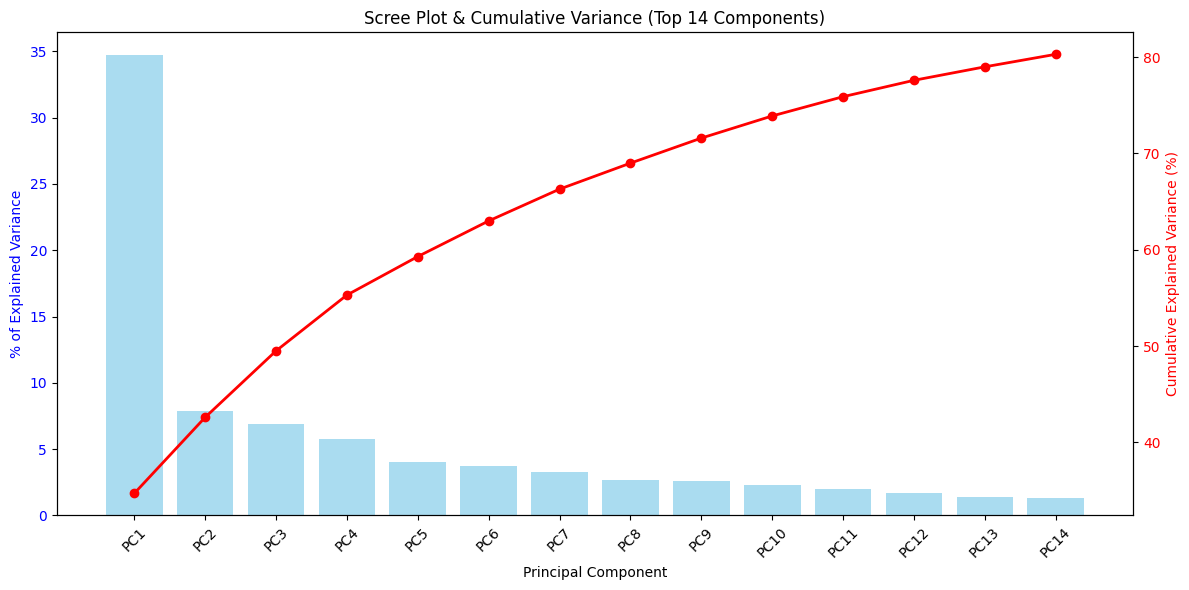

In [64]:
#Scree plot to see how many components should go into the final plot
import matplotlib.pyplot as plt

per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
cum_var = np.cumsum(per_var)

top_n = 14
labels = ['PC' + str(x) for x in range(1, top_n + 1)]
print(top_n)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for individual variance
ax1.bar(x=range(1, top_n + 1), height=per_var[:top_n], tick_label=labels, color='skyblue', alpha=0.7)
ax1.set_ylabel('% of Explained Variance', color='blue')
ax1.set_xlabel('Principal Component')
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(rotation=45)

# Line plot for cumulative variance
ax2 = ax1.twinx()
ax2.plot(range(1, top_n + 1), cum_var[:top_n], color='red', marker='o', linewidth=2)
ax2.set_ylabel('Cumulative Explained Variance (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title(f'Scree Plot & Cumulative Variance (Top {top_n} Components)')
plt.grid(False)
plt.tight_layout()
plt.show()

In [65]:
#Number of principal components that we keep
target_variance=80

total_pc=1
for i in cum_var:
  if i < target_variance:
    total_pc += 1
print(f"To keep at least {target_variance}% of the original information, we need to keep {total_pc} components.")


To keep at least 80% of the original information, we need to keep 14 components.


In [66]:
#Final PC DataFrame
cols_fin = ['date', 'bin', 'ret', 'ecm_spread', 
                 'ecm_spread_lag1', 'ecm_spread_lag2', 
                 'corn_Close', 'soybean_Close','corn_Volume', 
                 'soybean_Volume', 'corn_log_return', 'soybean_log_return']

df_fin = merged_data[cols_fin]

pca_columns = [f'PC{i+1}' for i in range(total_pc)] 
final_pca_data = pca_data[:, :total_pc]
df_pca = pd.DataFrame(final_pca_data, columns=pca_columns)

df_pca_fin = pd.concat([df_pca, df_fin], axis=1)
df_pca_fin = df_pca_fin.dropna()

print("Shape of our new reduced dataset:", df_pca_fin.shape)

df_pca_fin.head()

Shape of our new reduced dataset: (5299, 26)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,ret,ecm_spread,ecm_spread_lag1,ecm_spread_lag2,corn_Close,soybean_Close,corn_Volume,soybean_Volume,corn_log_return,soybean_log_return
0,10.405033,4.782327,1.643777,1.353854,-1.161833,-5.689426,1.788941,2.243069,-0.156246,0.030552,...,0.019714,-0.011870,-0.005685,-0.017214,201.50,534.00,1159.0,37,0.002484,0.007991
1,9.572913,3.518542,1.126765,2.316346,-1.600684,-4.052730,0.060894,3.070445,2.449150,-1.339983,...,-0.029472,0.007844,-0.011870,-0.005685,208.75,541.75,7093.0,35,0.035348,0.014409
2,7.043779,-2.791132,3.495484,10.496756,5.765555,0.551315,4.849476,6.209226,4.458287,2.129551,...,-0.035112,-0.021628,0.007844,-0.011870,206.75,551.75,1307.0,17,-0.009627,0.018290
3,6.186241,-1.442440,1.678157,10.455124,0.911845,-0.267795,3.960875,4.962322,1.123470,0.500505,...,-0.028338,-0.037732,-0.021628,0.007844,206.75,560.00,998.0,65,0.000000,0.014842
4,5.069231,2.830181,4.090727,7.502852,3.081133,-0.501125,6.383045,2.752001,1.434712,-0.822338,...,-0.023863,-0.032877,-0.037732,-0.021628,206.75,557.50,1091.0,10,0.000000,-0.004474


In [67]:
# Save PCA data
df_pca_fin.to_csv('PCA_data.csv', index=False)